In [3]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from torchvision.datasets import ImageFolder
from tqdm.auto import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

BASE_DIR = Path('.')
MODELS_DIR = BASE_DIR / 'saved_models'
MODELS_DIR.mkdir(exist_ok=True)

MONKEYS_DIR = BASE_DIR / 'data' / 'monkeys'
CATS_DOGS_DIR = BASE_DIR / 'data' / 'cats_dogs'


device: cuda


In [4]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'test_loss': [], 'test_acc': []}
    model.to(device)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        test_loss, test_acc, _, _ = evaluate_model(model, test_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        print(f'epoch {epoch + 1}/{epochs}: train_loss={train_loss:.4f} test_loss={test_loss:.4f} test_acc={test_acc:.4f}')

    return history


def evaluate_model(model, loader, criterion, device):
    model.eval()
    losses = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item() * X_batch.size(0))
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    mean_loss = sum(losses) / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    return mean_loss, acc, np.array(all_targets), np.array(all_preds)


def plot_losses(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['test_loss'], label='test')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def show_predictions(model, loader, class_names, device, n=8):
    model.eval()
    images, targets = next(iter(loader))
    images = images[:n].to(device)
    targets = targets[:n]

    with torch.no_grad():
        preds = model(images).argmax(dim=1).cpu()

    cols = min(n, 4)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, img, y_true, y_pred in zip(axes, images.cpu(), targets, preds):
        if img.shape[0] == 1:
            ax.imshow(img.squeeze(0), cmap='gray')
        else:
            ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
        ax.set_title(f'true={class_names[int(y_true)]}\npred={class_names[int(y_pred)]}')
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def show_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def visualize_first_conv(model, sample_batch, device, max_maps=8):
    first_conv = next(module for module in model.modules() if isinstance(module, nn.Conv2d))
    fmap = None

    def hook(_, __, output):
        nonlocal fmap
        fmap = output.detach().cpu()

    handle = first_conv.register_forward_hook(hook)
    model.eval()
    with torch.no_grad():
        model(sample_batch[:1].to(device))
    handle.remove()

    feature_maps = fmap[0, :max_maps]
    fig, axes = plt.subplots(1, len(feature_maps), figsize=(3 * len(feature_maps), 3))
    axes = np.array(axes).reshape(-1)
    for ax, fmap_one in zip(axes, feature_maps):
        ax.imshow(fmap_one, cmap='viridis')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def prepare_imagefolder_loaders(root_dir, image_size=224, batch_size=32, train_ratio=0.8):
    root_dir = Path(root_dir)
    if not root_dir.exists():
        print(f'Каталог не найден: {root_dir}')
        return None, None, None

    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
    ])
    dataset = ImageFolder(root=root_dir, transform=transform)
    train_size = int(len(dataset) * train_ratio)
    test_size = len(dataset) - train_size
    train_ds, test_ds = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return dataset.classes, train_loader, test_loader


## 1. Классификация предметов одежды (Fashion MNIST)
### 1.1 Решить задачу классификации, не используя сверточные слои


100%|██████████| 26.4M/26.4M [00:01<00:00, 14.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 856kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 12.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.0MB/s]


Fashion MLP params: 235146
epoch 1/8: train_loss=0.5479 test_loss=0.4450 test_acc=0.8362
epoch 2/8: train_loss=0.3983 test_loss=0.4077 test_acc=0.8497
epoch 3/8: train_loss=0.3622 test_loss=0.3807 test_acc=0.8636
epoch 4/8: train_loss=0.3376 test_loss=0.3681 test_acc=0.8683
epoch 5/8: train_loss=0.3207 test_loss=0.3556 test_acc=0.8742
epoch 6/8: train_loss=0.3072 test_loss=0.3463 test_acc=0.8734
epoch 7/8: train_loss=0.2940 test_loss=0.3434 test_acc=0.8787
epoch 8/8: train_loss=0.2849 test_loss=0.3343 test_acc=0.8780


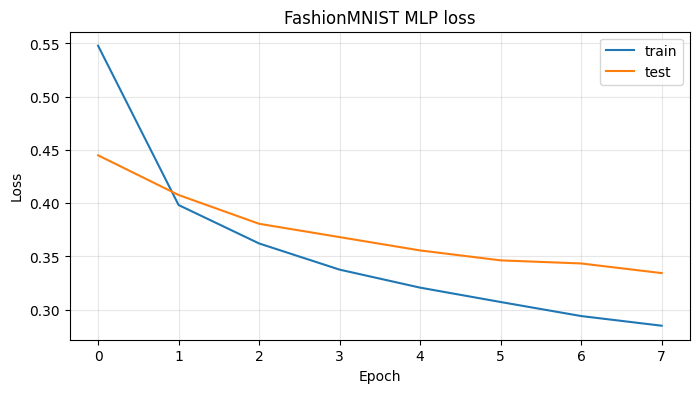

Fashion MLP accuracy: 0.878


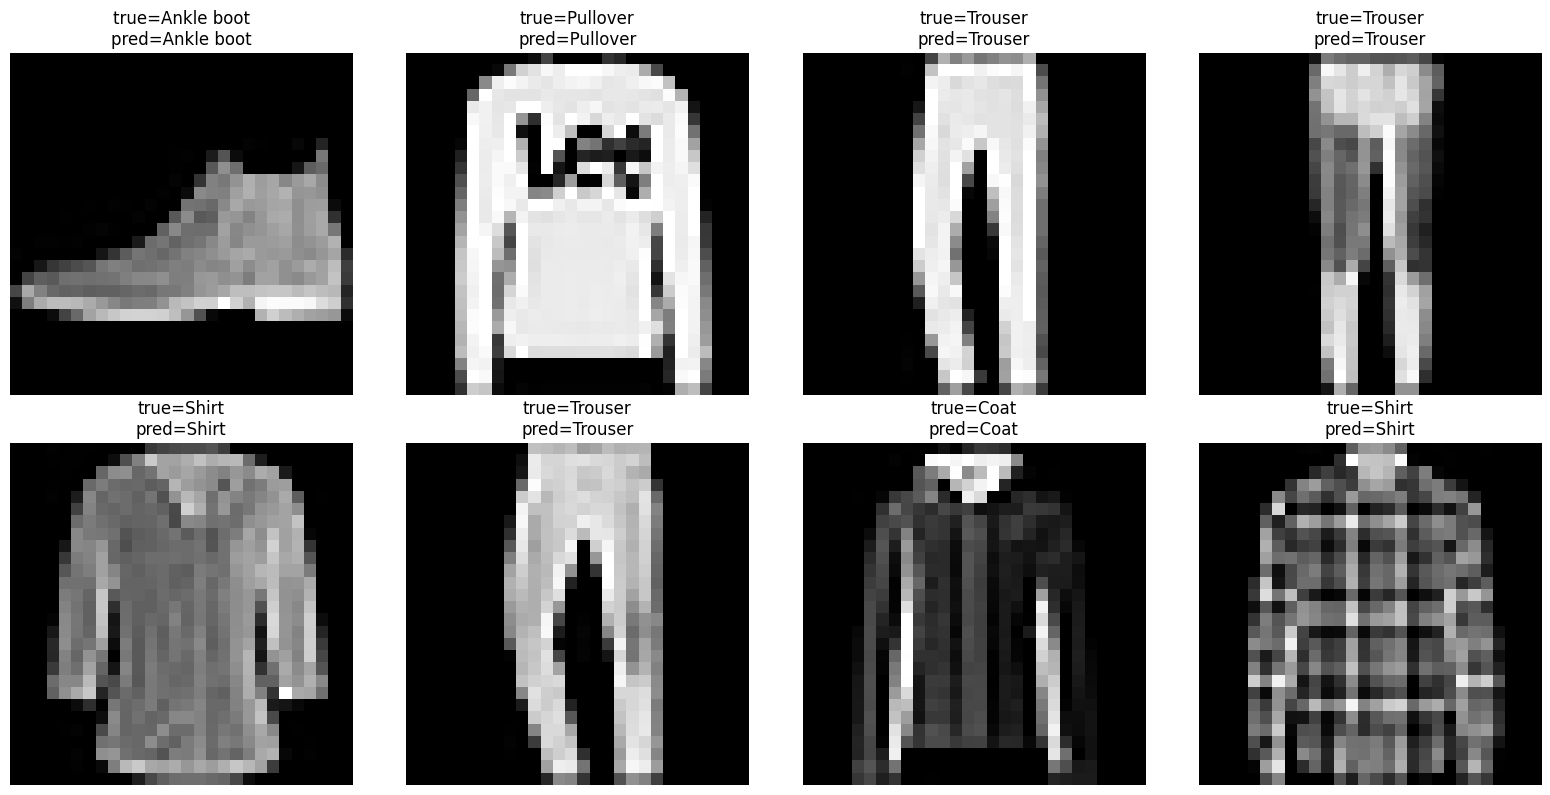

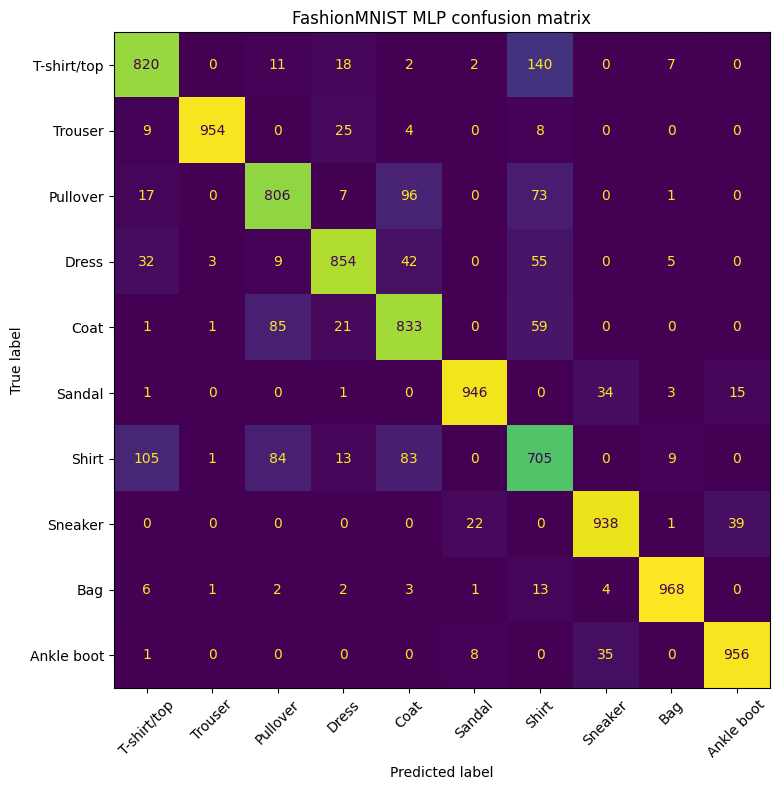

In [5]:
fashion_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

fashion_train = datasets.FashionMNIST(root='data', train=True, download=True, transform=fashion_transform)
fashion_test = datasets.FashionMNIST(root='data', train=False, download=True, transform=fashion_transform)

fashion_train_loader = DataLoader(fashion_train, batch_size=128, shuffle=True)
fashion_test_loader = DataLoader(fashion_test, batch_size=256, shuffle=False)
fashion_classes = fashion_train.classes

class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

fashion_mlp = FashionMLP()
print('Fashion MLP params:', count_parameters(fashion_mlp))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fashion_mlp.parameters(), lr=1e-3)
history_fashion_mlp = train_model(fashion_mlp, fashion_train_loader, fashion_test_loader, criterion, optimizer, epochs=8, device=device)
plot_losses(history_fashion_mlp, 'FashionMNIST MLP loss')

test_loss, test_acc, y_true, y_pred = evaluate_model(fashion_mlp, fashion_test_loader, criterion, device)
print('Fashion MLP accuracy:', test_acc)
show_predictions(fashion_mlp, fashion_test_loader, fashion_classes, device)
show_confusion(y_true, y_pred, fashion_classes, 'FashionMNIST MLP confusion matrix')
torch.save(fashion_mlp.state_dict(), MODELS_DIR / 'fashion_mlp.pth')


### 1.2 Решить задачу 1.1, используя сверточную нейронную сеть


Fashion CNN params: 421642
epoch 1/8: train_loss=0.5313 test_loss=0.3756 test_acc=0.8639
epoch 2/8: train_loss=0.3439 test_loss=0.3058 test_acc=0.8899
epoch 3/8: train_loss=0.2996 test_loss=0.2817 test_acc=0.9002
epoch 4/8: train_loss=0.2671 test_loss=0.2618 test_acc=0.9064
epoch 5/8: train_loss=0.2410 test_loss=0.2564 test_acc=0.9073
epoch 6/8: train_loss=0.2222 test_loss=0.2466 test_acc=0.9105
epoch 7/8: train_loss=0.2057 test_loss=0.2428 test_acc=0.9127
epoch 8/8: train_loss=0.1890 test_loss=0.2298 test_acc=0.9162


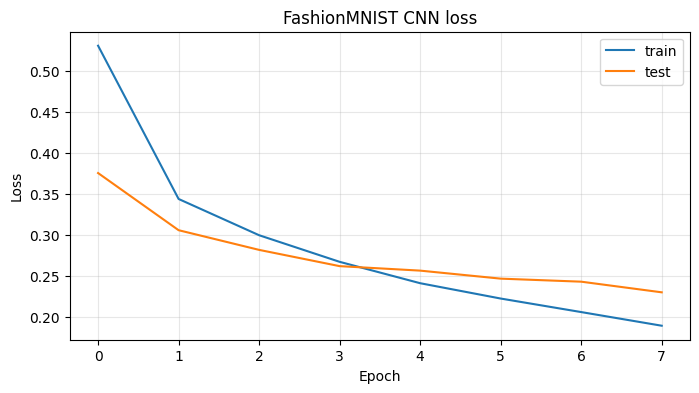

Fashion CNN accuracy: 0.9162


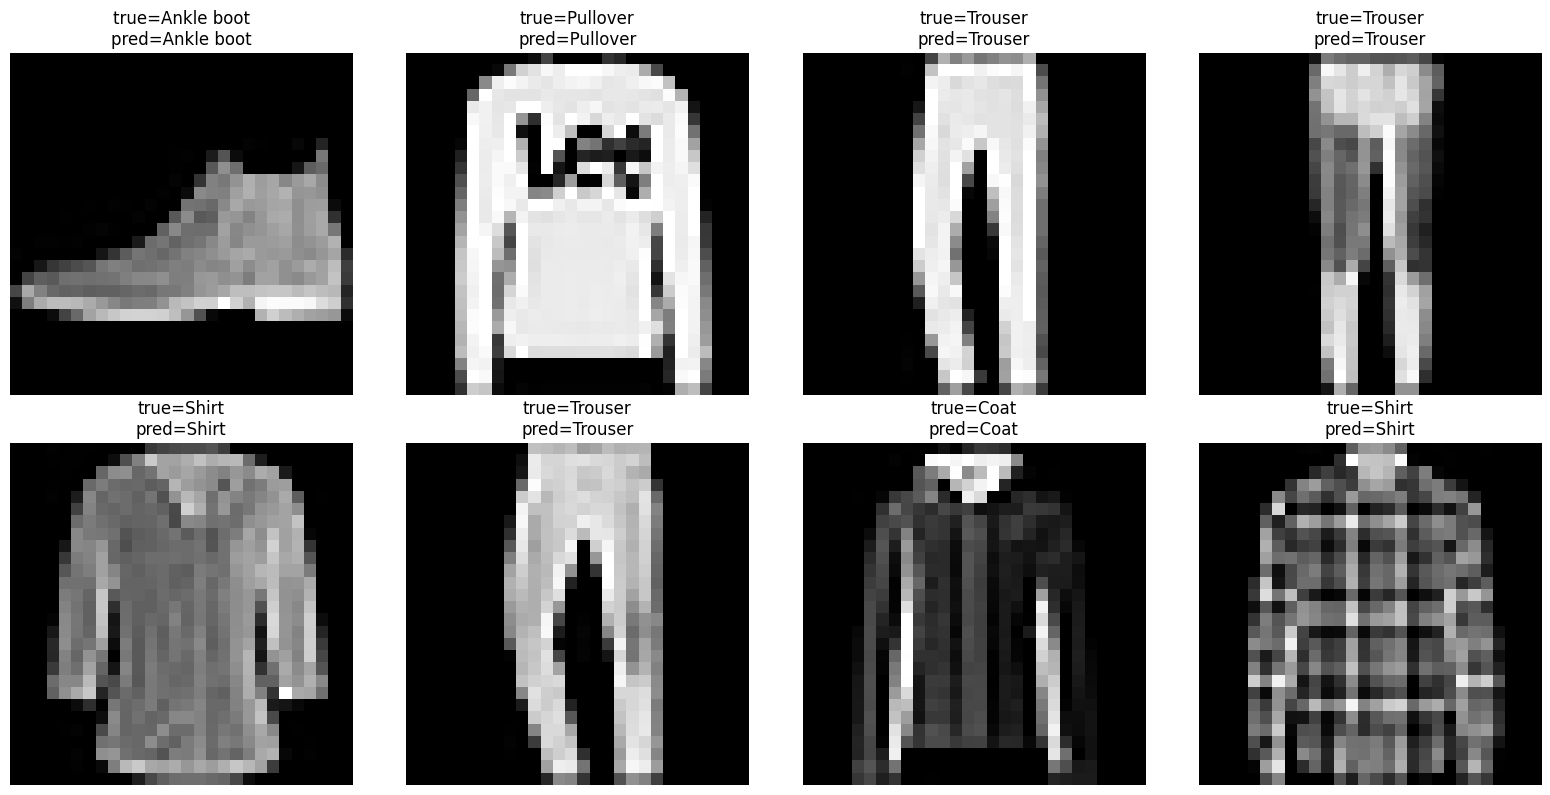

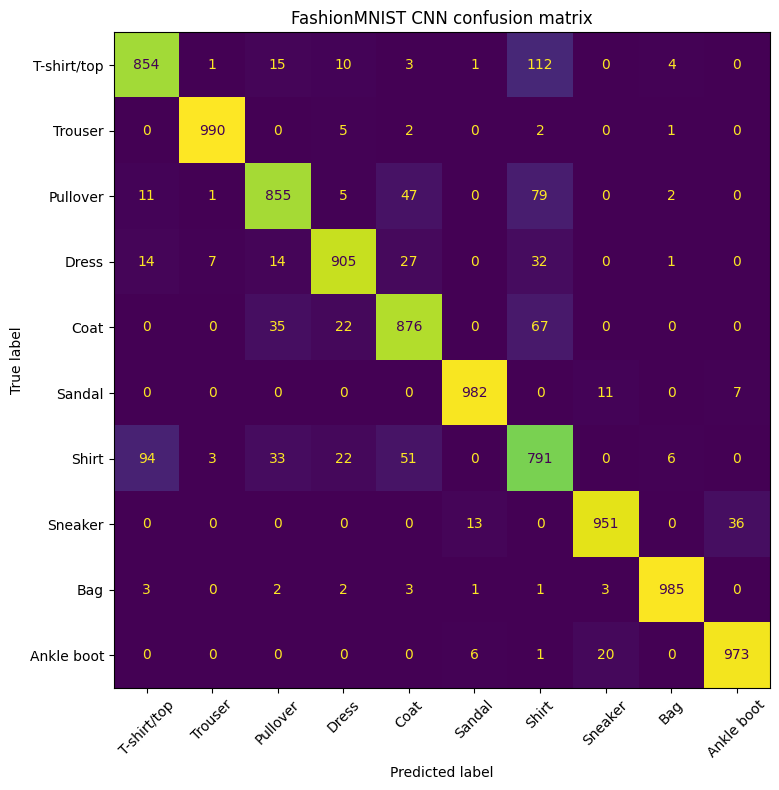

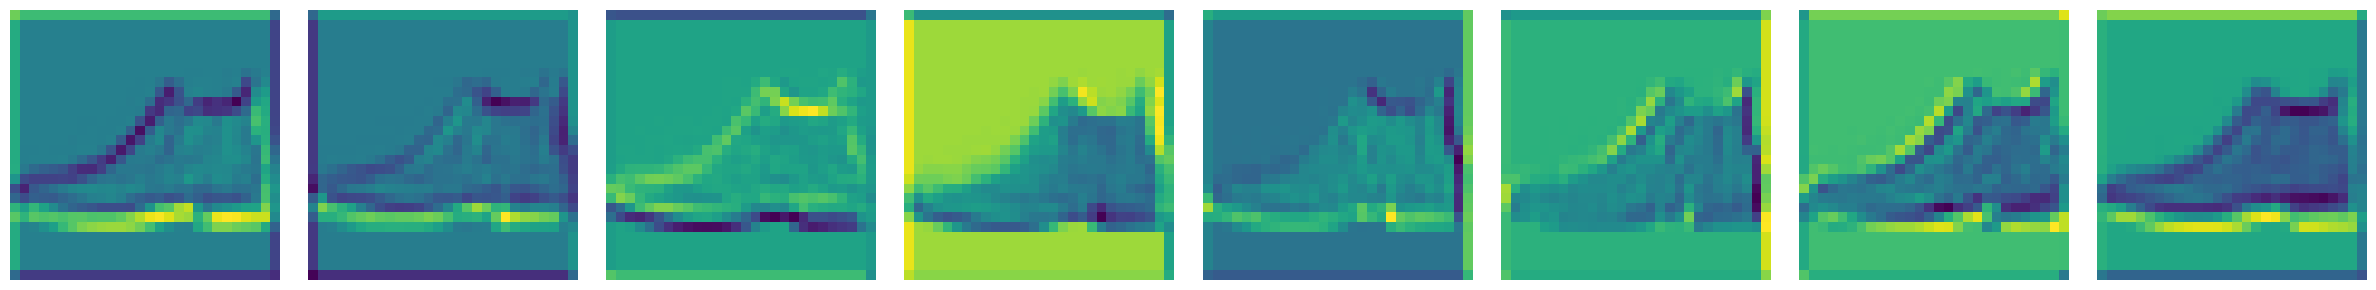

In [6]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

fashion_cnn = FashionCNN()
print('Fashion CNN params:', count_parameters(fashion_cnn))
optimizer = optim.Adam(fashion_cnn.parameters(), lr=1e-3)
history_fashion_cnn = train_model(fashion_cnn, fashion_train_loader, fashion_test_loader, criterion, optimizer, epochs=8, device=device)
plot_losses(history_fashion_cnn, 'FashionMNIST CNN loss')

test_loss, test_acc, y_true, y_pred = evaluate_model(fashion_cnn, fashion_test_loader, criterion, device)
print('Fashion CNN accuracy:', test_acc)
show_predictions(fashion_cnn, fashion_test_loader, fashion_classes, device)
show_confusion(y_true, y_pred, fashion_classes, 'FashionMNIST CNN confusion matrix')
visualize_first_conv(fashion_cnn, next(iter(fashion_test_loader))[0], device)
torch.save(fashion_cnn.state_dict(), MODELS_DIR / 'fashion_cnn.pth')


## 2. Классификация изображений (CIFAR-10)
### 2.1 Решить задачу классификации, не используя сверточные слои


100%|██████████| 170M/170M [00:14<00:00, 11.6MB/s] 
/home/aleksey/Documents/mirea_lab/6 sem/algo-ml/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR MLP params: 3411722
epoch 1/10: train_loss=1.6955 test_loss=1.5336 test_acc=0.4561
epoch 2/10: train_loss=1.5177 test_loss=1.4827 test_acc=0.4729
epoch 3/10: train_loss=1.4355 test_loss=1.4363 test_acc=0.5004
epoch 4/10: train_loss=1.3817 test_loss=1.4208 test_acc=0.5011
epoch 5/10: train_loss=1.3281 test_loss=1.4173 test_acc=0.5108
epoch 6/10: train_loss=1.2824 test_loss=1.3775 test_acc=0.5198
epoch 7/10: train_loss=1.2473 test_loss=1.3573 test_acc=0.5238
epoch 8/10: train_loss=1.2040 test_loss=1.3738 test_acc=0.5237
epoch 9/10: train_loss=1.1734 test_loss=1.3841 test_acc=0.5268
epoch 10/10: train_loss=1.1420 test_loss=1.3611 test_acc=0.5343


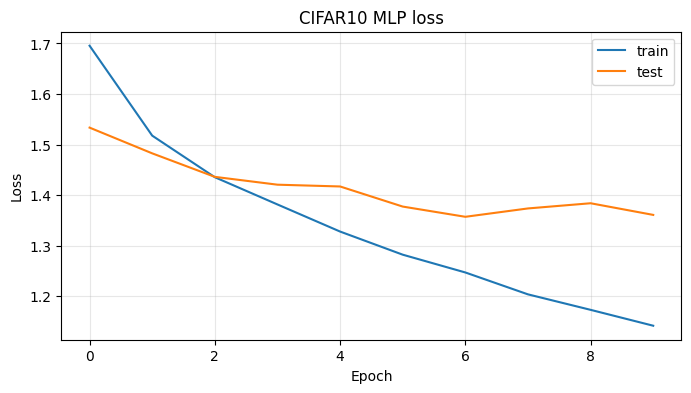

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7830755..2.0985878].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0004883].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9259666..2.075614].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4518033..1.8051611].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8783362..1.5660293].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9198096..1.3605304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9735969

CIFAR MLP accuracy: 0.5343


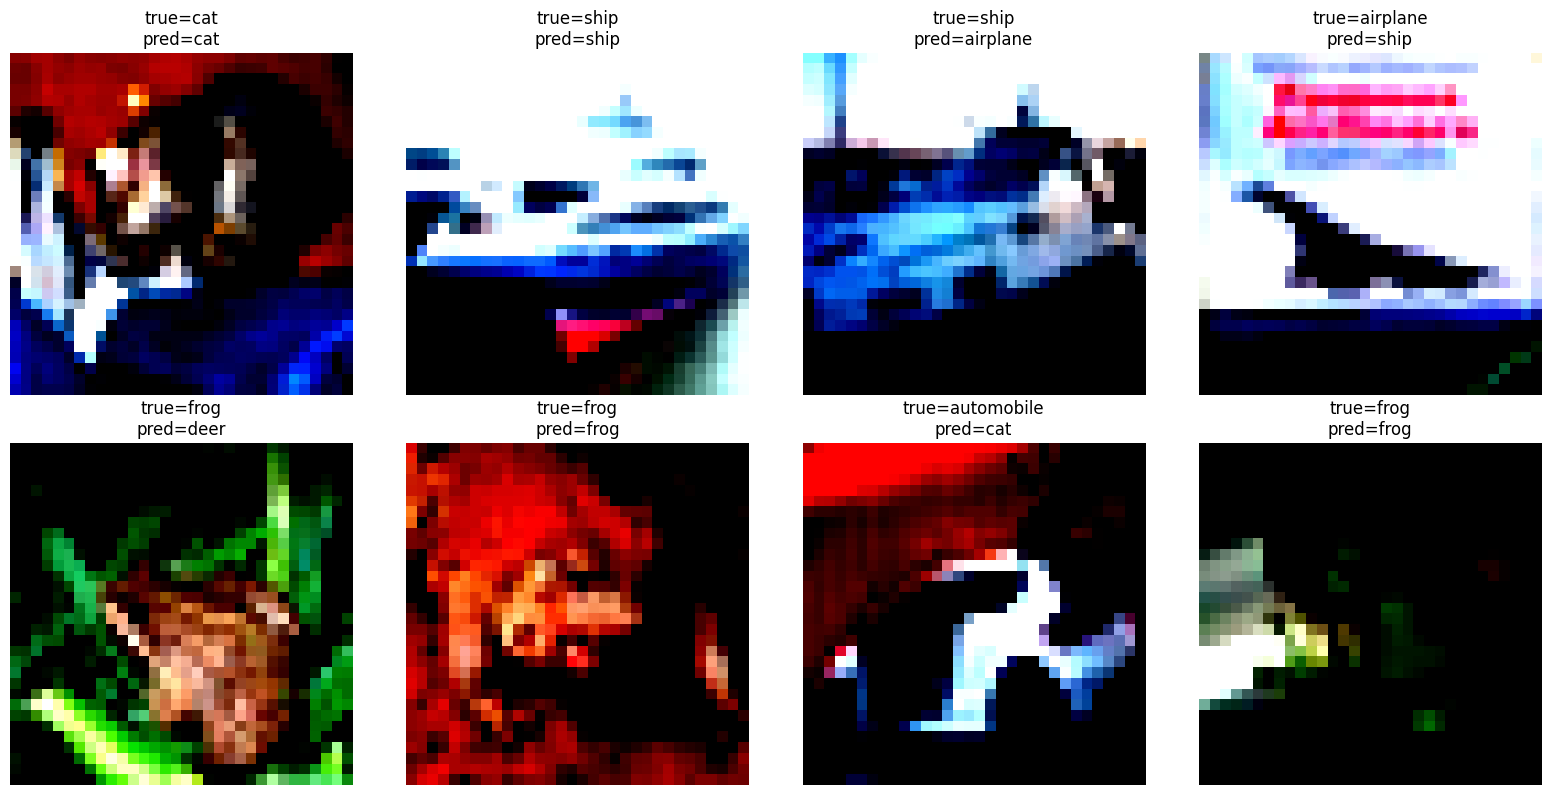

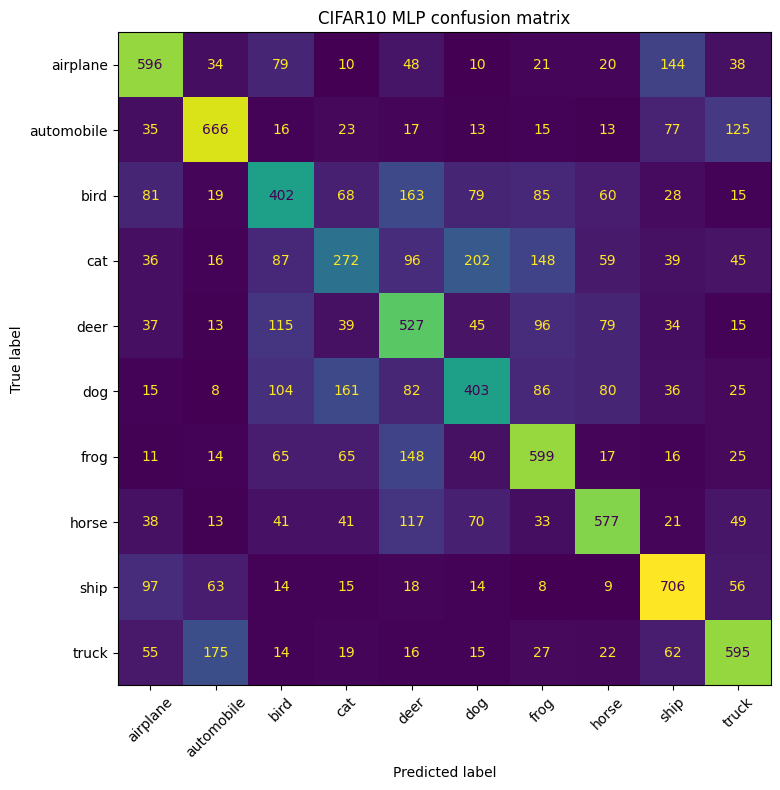

In [7]:
cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])

cifar_train = datasets.CIFAR10(root='data', train=True, download=True, transform=cifar_transform)
cifar_test = datasets.CIFAR10(root='data', train=False, download=True, transform=cifar_transform)

cifar_train_loader = DataLoader(cifar_train, batch_size=128, shuffle=True)
cifar_test_loader = DataLoader(cifar_test, batch_size=256, shuffle=False)
cifar_classes = cifar_train.classes

class CIFARMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)

cifar_mlp = CIFARMLP()
print('CIFAR MLP params:', count_parameters(cifar_mlp))
optimizer = optim.Adam(cifar_mlp.parameters(), lr=1e-3)
history_cifar_mlp = train_model(cifar_mlp, cifar_train_loader, cifar_test_loader, criterion, optimizer, epochs=10, device=device)
plot_losses(history_cifar_mlp, 'CIFAR10 MLP loss')

test_loss, test_acc, y_true, y_pred = evaluate_model(cifar_mlp, cifar_test_loader, criterion, device)
print('CIFAR MLP accuracy:', test_acc)
show_predictions(cifar_mlp, cifar_test_loader, cifar_classes, device)
show_confusion(y_true, y_pred, cifar_classes, 'CIFAR10 MLP confusion matrix')
torch.save(cifar_mlp.state_dict(), MODELS_DIR / 'cifar_mlp.pth')


### 2.2 Решить задачу 2.1, используя сверточную нейронную сеть


CIFAR CNN params: 2193226
epoch 1/12: train_loss=1.3567 test_loss=1.0206 test_acc=0.6311
epoch 2/12: train_loss=0.9113 test_loss=0.7999 test_acc=0.7213
epoch 3/12: train_loss=0.7294 test_loss=0.7290 test_acc=0.7458
epoch 4/12: train_loss=0.5997 test_loss=0.7140 test_acc=0.7553
epoch 5/12: train_loss=0.4851 test_loss=0.7070 test_acc=0.7652
epoch 6/12: train_loss=0.3884 test_loss=0.7461 test_acc=0.7643
epoch 7/12: train_loss=0.3090 test_loss=0.7662 test_acc=0.7718
epoch 8/12: train_loss=0.2525 test_loss=0.8328 test_acc=0.7703
epoch 9/12: train_loss=0.2005 test_loss=0.8914 test_acc=0.7645
epoch 10/12: train_loss=0.1685 test_loss=0.9119 test_acc=0.7682
epoch 11/12: train_loss=0.1490 test_loss=1.0028 test_acc=0.7658
epoch 12/12: train_loss=0.1323 test_loss=1.1228 test_acc=0.7610


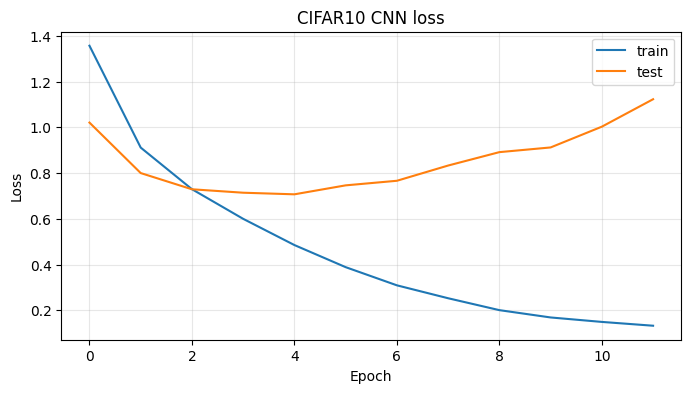

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7830755..2.0985878].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0004883].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9259666..2.075614].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4518033..1.8051611].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8783362..1.5660293].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9198096..1.3605304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9735969

CIFAR CNN accuracy: 0.761


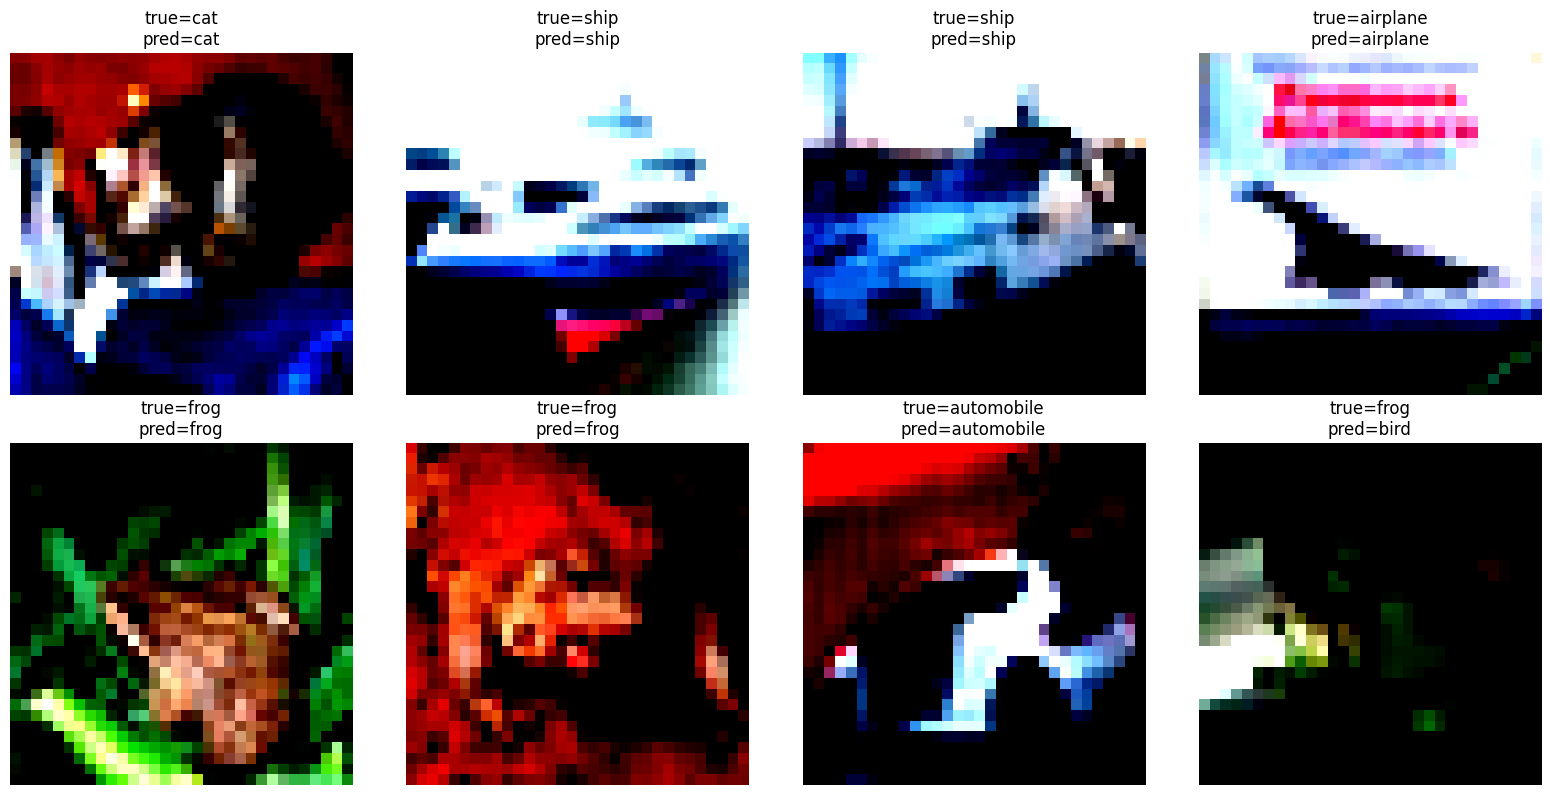

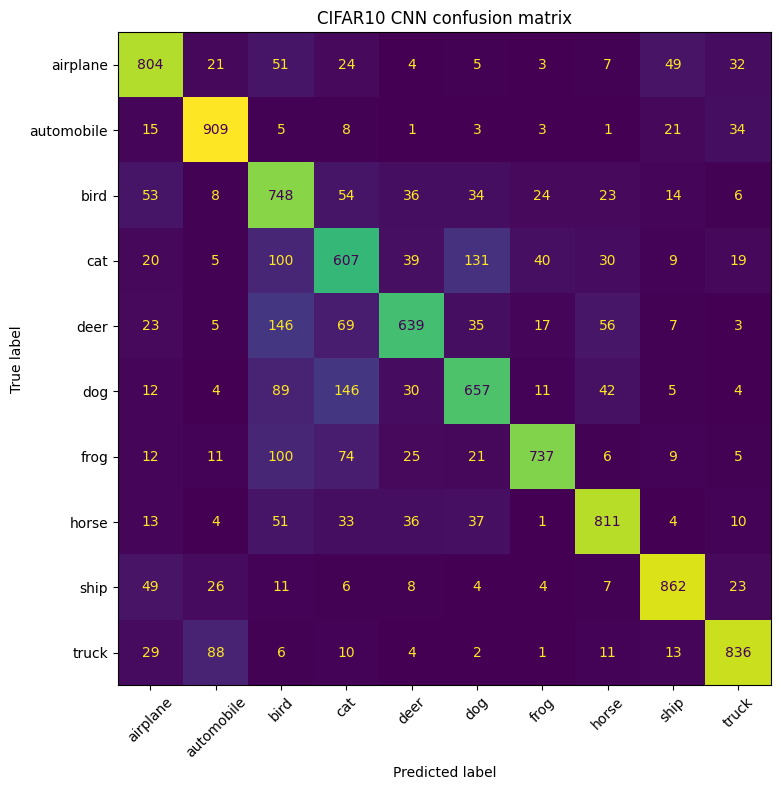

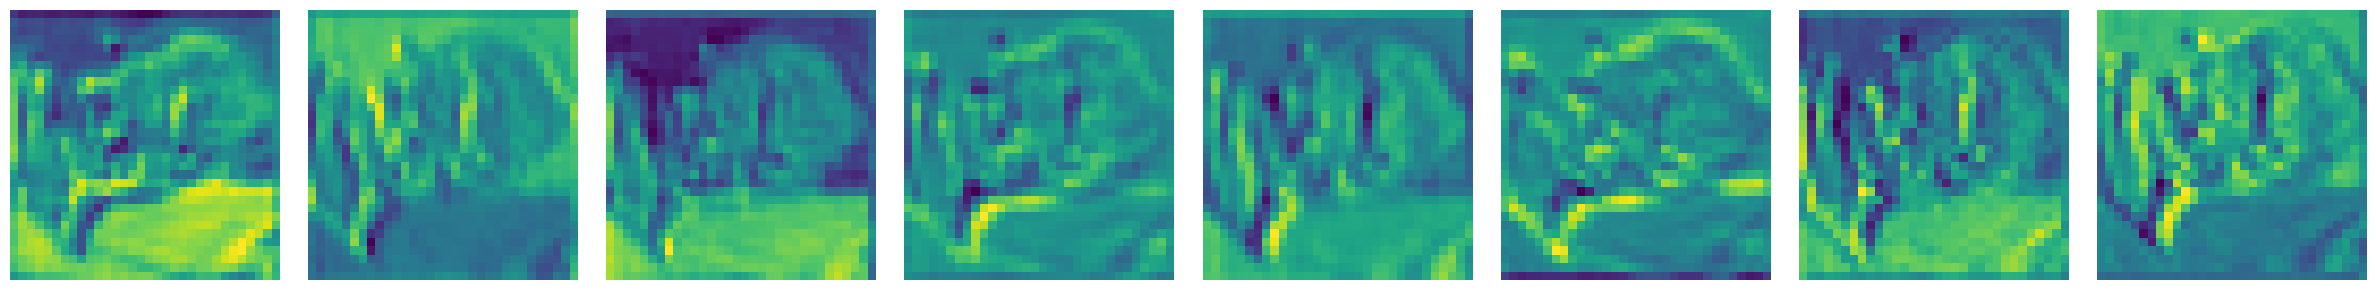

In [8]:
class CIFARCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cifar_cnn = CIFARCNN()
print('CIFAR CNN params:', count_parameters(cifar_cnn))
optimizer = optim.Adam(cifar_cnn.parameters(), lr=1e-3)
history_cifar_cnn = train_model(cifar_cnn, cifar_train_loader, cifar_test_loader, criterion, optimizer, epochs=12, device=device)
plot_losses(history_cifar_cnn, 'CIFAR10 CNN loss')

test_loss, test_acc, y_true, y_pred = evaluate_model(cifar_cnn, cifar_test_loader, criterion, device)
print('CIFAR CNN accuracy:', test_acc)
show_predictions(cifar_cnn, cifar_test_loader, cifar_classes, device)
show_confusion(y_true, y_pred, cifar_classes, 'CIFAR10 CNN confusion matrix')
visualize_first_conv(cifar_cnn, next(iter(cifar_test_loader))[0], device)
torch.save(cifar_cnn.state_dict(), MODELS_DIR / 'cifar_cnn.pth')


## 3. Загрузка изображений из внешних источников
### 3.1 Классификация обезьян через `ImageFolder`


In [9]:
monkey_classes, monkey_train_loader, monkey_test_loader = prepare_imagefolder_loaders(MONKEYS_DIR, image_size=160, batch_size=32)

if monkey_train_loader is not None:
    class MonkeyCNN(nn.Module):
        def __init__(self, n_classes):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1)),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(64, n_classes),
            )

        def forward(self, x):
            return self.classifier(self.features(x))

    monkey_model = MonkeyCNN(len(monkey_classes))
    optimizer = optim.Adam(monkey_model.parameters(), lr=1e-3)
    history_monkey = train_model(monkey_model, monkey_train_loader, monkey_test_loader, criterion, optimizer, epochs=12, device=device)
    plot_losses(history_monkey, 'Monkey classification loss')
    test_loss, test_acc, y_true, y_pred = evaluate_model(monkey_model, monkey_test_loader, criterion, device)
    print('Monkey accuracy:', test_acc)
    show_predictions(monkey_model, monkey_test_loader, monkey_classes, device)
    show_confusion(y_true, y_pred, monkey_classes, 'Monkey confusion matrix')
    torch.save(monkey_model.state_dict(), MODELS_DIR / 'monkey_cnn.pth')


Каталог не найден: data/monkeys


### 3.2 Классификация собак и кошек через `ImageFolder`


In [10]:
cats_dogs_classes, cats_dogs_train_loader, cats_dogs_test_loader = prepare_imagefolder_loaders(CATS_DOGS_DIR, image_size=160, batch_size=32)

if cats_dogs_train_loader is not None:
    class CatsDogsCNN(nn.Module):
        def __init__(self, n_classes):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1)),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(64, n_classes),
            )

        def forward(self, x):
            return self.classifier(self.features(x))

    cats_dogs_model = CatsDogsCNN(len(cats_dogs_classes))
    optimizer = optim.Adam(cats_dogs_model.parameters(), lr=1e-3)
    history_cats_dogs = train_model(cats_dogs_model, cats_dogs_train_loader, cats_dogs_test_loader, criterion, optimizer, epochs=12, device=device)
    plot_losses(history_cats_dogs, 'Cats vs dogs loss')
    test_loss, test_acc, y_true, y_pred = evaluate_model(cats_dogs_model, cats_dogs_test_loader, criterion, device)
    print('Cats vs dogs accuracy:', test_acc)
    show_predictions(cats_dogs_model, cats_dogs_test_loader, cats_dogs_classes, device)
    show_confusion(y_true, y_pred, cats_dogs_classes, 'Cats vs dogs confusion matrix')
    torch.save(cats_dogs_model.state_dict(), MODELS_DIR / 'cats_dogs_cnn.pth')


Каталог не найден: data/cats_dogs


## 4. Transfer Learning
### 4.1 Обезьяны + VGG16


In [11]:
transfer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def prepare_transfer_loaders(root_dir, batch_size=32, train_ratio=0.8):
    root_dir = Path(root_dir)
    if not root_dir.exists():
        print(f'Каталог не найден: {root_dir}')
        return None, None, None
    dataset = ImageFolder(root=root_dir, transform=transfer_transform)
    train_size = int(len(dataset) * train_ratio)
    test_size = len(dataset) - train_size
    train_ds, test_ds = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))
    return dataset.classes, DataLoader(train_ds, batch_size=batch_size, shuffle=True), DataLoader(test_ds, batch_size=batch_size, shuffle=False)

monkey_classes_tl, monkey_train_tl, monkey_test_tl = prepare_transfer_loaders(MONKEYS_DIR)

if monkey_train_tl is not None:
    vgg16_full = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    vgg16_full.classifier[-1] = nn.Linear(vgg16_full.classifier[-1].in_features, len(monkey_classes_tl))
    optimizer = optim.Adam(vgg16_full.parameters(), lr=1e-4)
    history_vgg_full = train_model(vgg16_full, monkey_train_tl, monkey_test_tl, criterion, optimizer, epochs=5, device=device)
    _, acc_full, _, _ = evaluate_model(vgg16_full, monkey_test_tl, criterion, device)
    print('VGG16 full fine-tuning accuracy:', acc_full)

    vgg16_head = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    for param in vgg16_head.parameters():
        param.requires_grad = False
    for param in vgg16_head.classifier.parameters():
        param.requires_grad = True
    vgg16_head.classifier[-1] = nn.Linear(vgg16_head.classifier[-1].in_features, len(monkey_classes_tl))
    optimizer = optim.Adam(vgg16_head.classifier.parameters(), lr=1e-4)
    history_vgg_head = train_model(vgg16_head, monkey_train_tl, monkey_test_tl, criterion, optimizer, epochs=5, device=device)
    _, acc_head, _, _ = evaluate_model(vgg16_head, monkey_test_tl, criterion, device)
    print('VGG16 classifier-only fine-tuning accuracy:', acc_head)


Каталог не найден: data/monkeys


### 4.2 Собаки и кошки + предобученная модель (ResNet18)


In [12]:
cats_dogs_classes_tl, cats_dogs_train_tl, cats_dogs_test_tl = prepare_transfer_loaders(CATS_DOGS_DIR)

if cats_dogs_train_tl is not None:
    resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    resnet18.fc = nn.Linear(resnet18.fc.in_features, len(cats_dogs_classes_tl))
    optimizer = optim.Adam(resnet18.parameters(), lr=1e-4)
    history_resnet = train_model(resnet18, cats_dogs_train_tl, cats_dogs_test_tl, criterion, optimizer, epochs=5, device=device)
    _, acc_resnet, y_true, y_pred = evaluate_model(resnet18, cats_dogs_test_tl, criterion, device)
    print('ResNet18 cats vs dogs accuracy:', acc_resnet)
    show_predictions(resnet18, cats_dogs_test_tl, cats_dogs_classes_tl, device)
    show_confusion(y_true, y_pred, cats_dogs_classes_tl, 'ResNet18 cats vs dogs confusion matrix')


Каталог не найден: data/cats_dogs
